# Importing Lib's & Data

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Normalization, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
!unzip /content/myzipped-8-25-2025-10-37-52-am.zip

Archive:  /content/myzipped-8-25-2025-10-37-52-am.zip
  inflating: archive_(1).zip         


In [3]:
!unzip "/content/archive_(1).zip" -d "/content/images"

Streaming output truncated to the last 5000 lines.
  inflating: /content/images/images/validation/fear/8797.jpg  
  inflating: /content/images/images/validation/fear/8818.jpg  
  inflating: /content/images/images/validation/fear/886.jpg  
  inflating: /content/images/images/validation/fear/9037.jpg  
  inflating: /content/images/images/validation/fear/9040.jpg  
  inflating: /content/images/images/validation/fear/9101.jpg  
  inflating: /content/images/images/validation/fear/911.jpg  
  inflating: /content/images/images/validation/fear/9179.jpg  
  inflating: /content/images/images/validation/fear/9205.jpg  
  inflating: /content/images/images/validation/fear/9232.jpg  
  inflating: /content/images/images/validation/fear/9251.jpg  
  inflating: /content/images/images/validation/fear/9261.jpg  
  inflating: /content/images/images/validation/fear/9281.jpg  
  inflating: /content/images/images/validation/fear/9302.jpg  
  inflating: /content/images/images/validation/fear/9333.jpg  
  infl

In [4]:
data_directory = '/content/images/images'
train_directory = os.path.join(data_directory, 'train')
validation_directory = os.path.join(data_directory, 'validation')

# Setting Data Generators

In [5]:
train_dataGen = ImageDataGenerator(
    rescale = 1/ 255,
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip = True
)

validation_dataGen = ImageDataGenerator(rescale= 1 / 255)
# Proceed with Data Generators(Use to feed Neural Network.)
train_generator = train_dataGen.flow_from_directory(
    train_directory,
    target_size = (48, 48),
    batch_size = 64,
    class_mode = 'categorical',
    color_mode = 'grayscale'
)

validation_generator = validation_dataGen.flow_from_directory(
    validation_directory,
    target_size = (48, 48),
    batch_size= 64,
    class_mode = 'categorical',
    color_mode = 'grayscale'
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


# Plotting

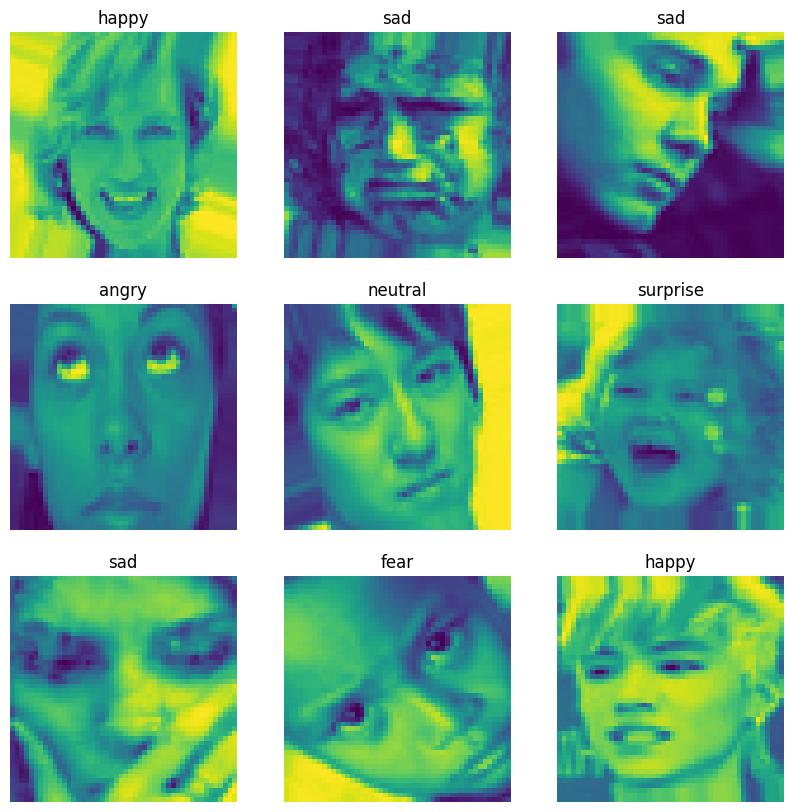

In [6]:
class_name = list(train_generator.class_indices.keys()) # It gives the name of emotion classes.
images, labels = next(train_generator) # Retrives single batch of images & their corresponding.

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3,3, i + 1)
    plt.imshow(images[i])
    plt.title(class_name[np.argmax(labels[i])]) # finds the index of max value.
    plt.axis('off')
plt.show()

# Building Model

In [7]:
model = Sequential([
    Conv2D(64, (3, 3), activation= 'relu', input_shape= (48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation= 'relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(256, (3,3), activation= 'relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation= 'relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(7, activation= 'softmax')
])

model.compile(optimizer= 'Adam', loss= 'categorical_crossentropy', metrics= ['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,474,759 (9.44 MB)

 Trainable params: 2,472,839 (9.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

# Model Traning & Evaluation

In [8]:
early_stop = EarlyStopping(monitor= 'val_loss', patience= 5, restore_best_weights= True)
reduce_lr = ReduceLROnPlateau(monitor= 'val_loss', factor= 0.2, patience= 5, verbose= 1, min_lr= 1e-6)

history = model.fit(
    train_generator,
    validation_data= validation_generator,
    epochs= 5,
    callbacks= [early_stop, reduce_lr]
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


451/451 ━━━━━━━━━━━━━━━━━━━━ 278s 610ms/step - accuracy: 0.2573 - loss: 2.1104 - val_accuracy: 0.2754 - val_loss: 1.9289 - learning_rate: 0.0010
Epoch 2/5
451/451 ━━━━━━━━━━━━━━━━━━━━ 274s 608ms/step - accuracy: 0.3846 - loss: 1.6218 - val_accuracy: 0.4193 - val_loss: 1.5149 - learning_rate: 0.0010
Epoch 3/5
451/451 ━━━━━━━━━━━━━━━━━━━━ 300s 665ms/step - accuracy: 0.4355 - loss: 1.4737 - val_accuracy: 0.4331 - val_loss: 1.4801 - learning_rate: 0.0010
Epoch 4/5
451/451 ━━━━━━━━━━━━━━━━━━━━ 304s 674ms/step - accuracy: 0.4726 - loss: 1.3809 - val_accuracy: 0.4853 - val_loss: 1.3441 - learning_rate: 0.0010
Epoch 5/5
451/451 ━━━━━━━━━━━━━━━━━━━━ 306s 679ms/step - accuracy: 0.5006 - loss: 1.3067 - val_accuracy: 0.5140 - val_loss: 1.2848 - learning_rate: 0.0010


In [9]:
y_true = []
y_pred = []
for i in range(len(validation_generator)):
    val_imgs, val_labels = next(validation_generator) # gets a batch of images.
    predictions = model.predict(val_imgs)
    y_true.extend(np.argmax(val_labels, axis=1))
    y_pred.extend(np.argmax(predictions, axis=1)) # Are in encoded format converts them into intger class.

print(classification_report(y_true, y_pred, target_names=class_name))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
2/2 ━━━━━━━

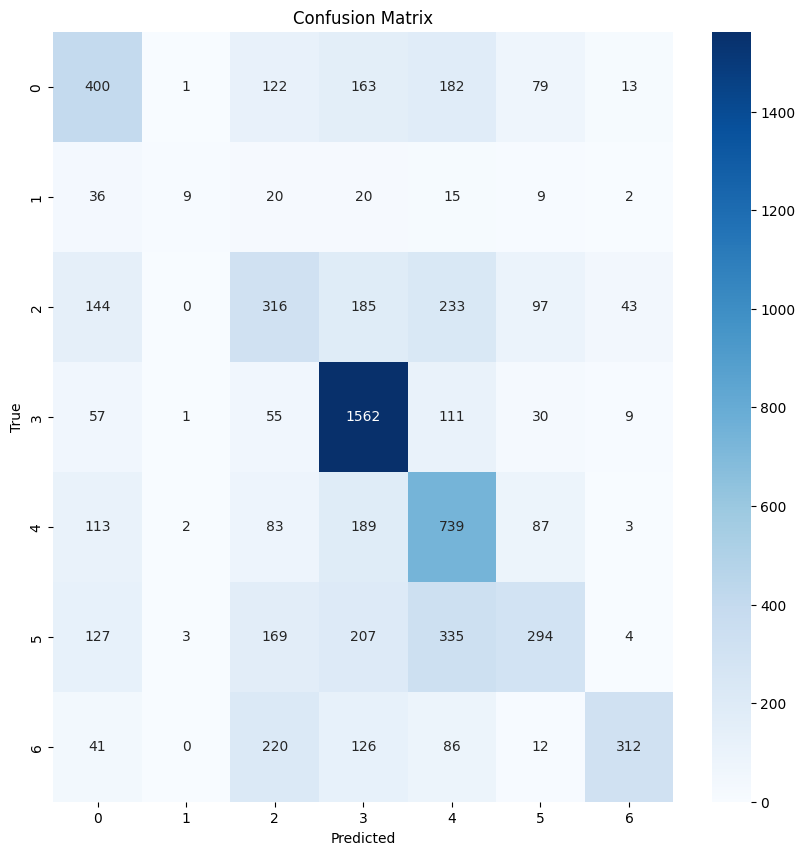

In [10]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize= (10, 10))
sns.heatmap(cm, annot= True, fmt= 'd', cmap= 'Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Prediction Function

In [11]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

def detect_emotions(img_path):
    img = image.load_img(img_path, target_size= (48, 48), color_mode= 'grayscale')
    img_array = image.img_to_array(img) / 255
    img_array = np.expand_dims(img_array, axis= 0)

    predict = model.predict(img_array)
    img_index = np.argmax(predict)
    pred_class = class_name[img_index] # converts raw output into meaningfull emotions.
    confidence = round(predict[0][img_index] * 100, 2) # Measure how sure the model is about it's prediction.

    plt.imshow(img, cmap= 'gray')
    plt.title(f'Predict Emotion: {pred_class} ({confidence}%)')
    plt.axis('off')
    plt.show()

    return pred_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


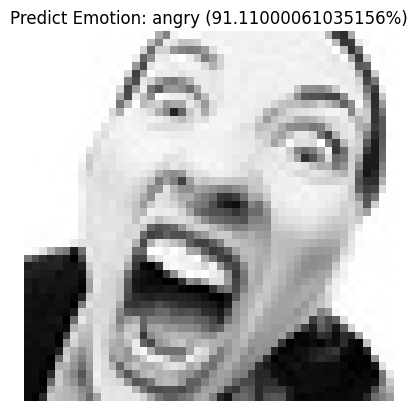

Emotions: angry, Confidence: 91.11000061035156


In [12]:
# Test1
predict_emotions, confidence = detect_emotions('/content/images/images/images/train/fear/11394.jpg')
print(f'Emotions: {predict_emotions}, Confidence: {confidence}')

# Saving Model.

In [13]:
model.save('Facial_Emotion_Detection.h5')

import pickle
pickle.dump(model, open('model.pkl', 'wb'))